# **Análisis exploratorio de datos**

Antes de construir el modelo de clasificación para predecir el tiempo de entrega (`delivery_time_local` - `courier_started_order_local`), es fundamental comprender la estructura, calidad y comportamiento de los datos.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Carga de datos
df = pd.read_csv("/content/drive/MyDrive/Reto_IA/glovo_ops_data_final.csv")

In [ ]:
# Dimensión del dataset
df.shape

(63646, 21)

El dataset contiene:
- 63.646 observaciones
- 21 variables

In [ ]:
df.head()

,order_id,customer_id,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,description,activation_time_local,...,pickup_time_local,delivery_time_local,tranport_type,rating,bad_rating_reason,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
0,32.0,700734,441.0,10887.0,Pharmacie,WALL - Partner,19.97,4.9,1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...,2019-10-01 09:21:34.000,...,2019-10-01 09:34:55.904,2019-10-01 09:50:02.000,MOTORBIKE,5.0,NaN,48.861046,2.275441,48.855068,2.283378,66
1,29.0,1648235,239.0,3705.0,Starbucks,WALL - NonPartner,10.50,4.9,"1 x Caffe Latte - Tall, Espresso Roast Class...",2019-10-01 09:18:30.000,...,2019-10-01 09:36:02.133,2019-10-01 09:47:39.000,BICYCLE,NaN,NaN,48.871578,2.304495,48.867017,2.292787,40
2,292.0,13527080,351.0,1035.0,Starbucks,WALL - NonPartner,10.35,4.9,Venti Latte Vanille Glace avec seulement 2 pom...,2019-10-01 15:04:50.000,...,2019-10-01 15:25:37.131,2019-10-01 15:34:52.000,MOTORBIKE,5.0,NaN,48.855461,2.360776,48.866713,2.364773,29
3,743.0,275173,391.0,NaN,NaN,COURIER,6.60,6.6,Lunettes,2019-10-02 10:08:38.000,...,2019-10-02 10:30:24.559,2019-10-02 10:50:13.000,MOTORBIKE,NaN,NaN,48.859665,2.285694,48.884335,2.259989,54
4,838.0,1105241,263.0,51106.0,Franprix,WALL - Partner,13.10,3.9,"1 x Emmental rape 29% - Franprix - 3x35g - 1,4...",2019-10-02 12:12:09.000,...,2019-10-02 12:31:21.010,2019-10-02 12:38:04.000,MOTORBIKE,5.0,NaN,48.863417,2.361240,48.868087,2.371050,77


## **1. Eliminación de variables irrelevantes**

Se eliminan variables que:
- son identificadores (no aportan información predictiva directa)
- o no están disponibles en el momento de la predicción (*data leakage*)

In [ ]:
df_mod = df.copy()
df_mod = df_mod.drop(columns=['order_id', 'customer_id', 'courier_id',	'store_address_id', 'bad_rating_reason', 'rating'])

In [ ]:
df.isna().sum()

,0
order_id,0
customer_id,0
courier_id,0
store_address_id,11628
store_name,11628
vertical,0
gtv,0
delivery_fee,0
description,32
activation_time_local,0


## **2. Tipos de variables**

Evaluamos el tipo de dato representado en cada columna:

In [ ]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63646 entries, 0 to 63645
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   store_name                   52018 non-null  object 
 1   vertical                     63646 non-null  object 
 2   gtv                          63646 non-null  float64
 3   delivery_fee                 63646 non-null  float64
 4   description                  63614 non-null  object 
 5   activation_time_local        63646 non-null  object 
 6   courier_started_order_local  63642 non-null  object 
 7   pickup_time_local            63646 non-null  object 
 8   delivery_time_local          63646 non-null  object 
 9   tranport_type                63646 non-null  object 
 10  pickup_latitude              63646 non-null  float64
 11  pickup_longitude             63646 non-null  float64
 12  delivery_latitude            63646 non-null  float64
 13  delivery_longitu

- Variables numéricas: `gtv`, `delivery_fee`, `saturation` y coordenadas geográficas.
- Variables categóricas: `store_name`, `vertical` y `tranport_type`.
- Variables temporales (mal tipadas como `object`): `activation_time_local`,`courier_started_order_local`, `pickup_time_local` y `delivery_time_local`.

Las variables temporales deben convertirse a formato `datetime` para poder calcular la variable objetivo y generar features temporales.

In [ ]:
date_cols = [
    'activation_time_local',
    'courier_started_order_local',
    'pickup_time_local',
    'delivery_time_local'
]

for col in date_cols:
    df_mod[col] = pd.to_datetime(df_mod[col], errors='coerce')

Por otro lado, las coordenadas geográficas no son directamente interpretables por modelos, pero sí lo es la distancia entre origen y destino.

Se calcula usando la fórmula de Haversine:

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radio Tierra en km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df_mod["distance_km"] = haversine(
    df_mod["pickup_latitude"],
    df_mod["pickup_longitude"],
    df_mod["delivery_latitude"],
    df_mod["delivery_longitude"]
)

Como la distancia ya captura la información relevante, para evitar multicolinealidad y ruido, eliminamos las coordenadas del modelo.

In [ ]:
df_mod = df_mod.drop(columns=[
    "pickup_latitude",
    "pickup_longitude",
    "delivery_latitude",
    "delivery_longitude"
])

In [ ]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63646 entries, 0 to 63645
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   store_name                   52018 non-null  object        
 1   vertical                     63646 non-null  object        
 2   gtv                          63646 non-null  float64       
 3   delivery_fee                 63646 non-null  float64       
 4   description                  63614 non-null  object        
 5   activation_time_local        63646 non-null  datetime64[ns]
 6   courier_started_order_local  63642 non-null  datetime64[ns]
 7   pickup_time_local            63646 non-null  datetime64[ns]
 8   delivery_time_local          63646 non-null  datetime64[ns]
 9   tranport_type                63646 non-null  object        
 10  saturation                   63646 non-null  int64         
 11  distance_km                  63646 non-nu

## **3. Análisis de valores nulos**

Este cálculo permite conocer el porcentaje de valores faltantes por variable.

In [ ]:
(df_mod.isnull().mean() * 100).sort_values(ascending=False)

,0
store_name,18.269805
description,0.050278
courier_started_order_local,0.006285
vertical,0.000000
delivery_fee,0.000000
gtv,0.000000
activation_time_local,0.000000
pickup_time_local,0.000000
delivery_time_local,0.000000
tranport_type,0.000000


- `store_name`

Presenta un 18.26% de missing values. Esto puede deberse a determinados tipos de pedidos donde no existe una tienda física.

In [ ]:
df_mod[df_mod['store_name'].isnull()]['vertical'].value_counts()

,count
vertical,
COURIER,11628


En pedidos tipo `COURIER` no existe tienda, el servicio es punto a punto (envíos personales). Por lo que mantenemos los nulos y creamos una categoría:

In [ ]:
df_mod['store_name'] = df_mod['store_name'].fillna('NO_STORE')

- `description`

Tiene muy pocos valores nulos, se eliminan.

In [ ]:
df_mod = df_mod.dropna(subset=['description'])

- `courier_started_order_local`

Se trata de una variable crítica, ya que se usa en el target. Se eliminan esos registros.

In [ ]:
df_mod = df_mod.dropna(subset=['courier_started_order_local'])

## **4. Análisis de variables numéricas**

### **4.1 Distribución de variables**

El análisis de las distribuciones permite identificar la forma de las variables y posibles patrones relevantes.

- **Estadísticos descriptivos**

In [ ]:
cols_num = ['gtv',	'delivery_fee',	'distance_km', 'saturation']
df_mod[cols_num].describe().T

,count,mean,std,min,25%,50%,75%,max
gtv,63610.0,23.481694,17.366889,0.000000,12.900000,18.400000,28.500000,346.620000
delivery_fee,63610.0,5.569461,3.662207,0.000000,3.900000,3.900000,6.900000,23.900000
distance_km,63610.0,2.461332,1.686094,0.006302,1.241392,2.092541,3.257787,14.179735
saturation,63610.0,77.770539,36.110815,20.000000,51.000000,73.000000,98.000000,239.000000


- **Análisis de histogramas**

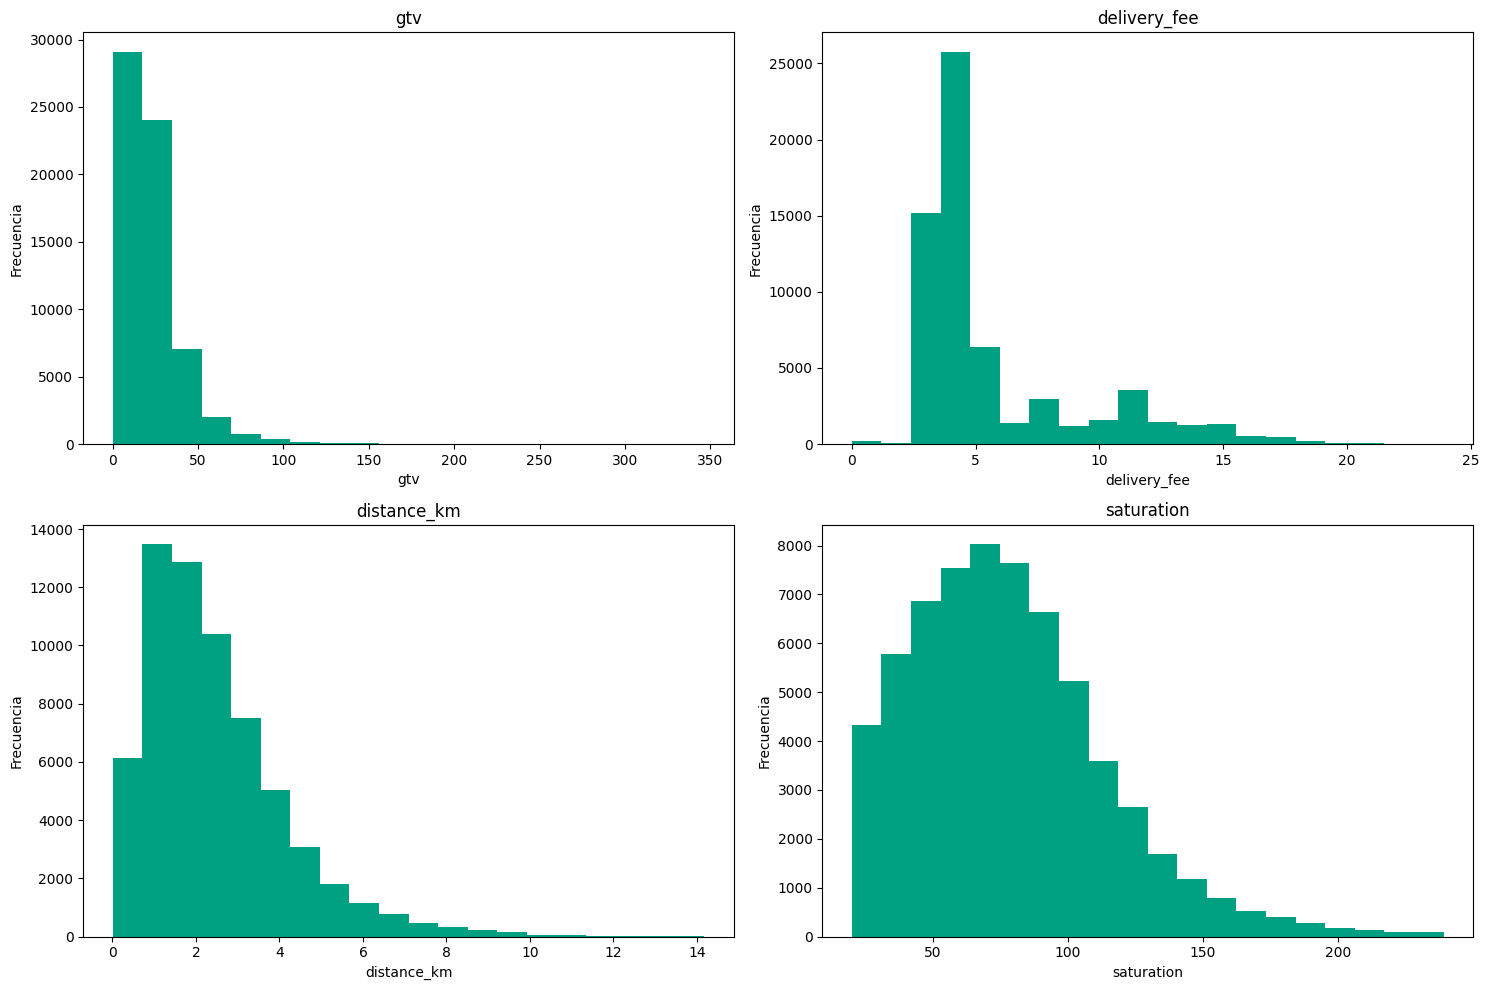

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes = axes.flatten()

for i, col in enumerate(cols_num):
    axes[i].hist(df_mod[col], bins=20, color='#00A082')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

- `gtv`

Distribución fuertemente sesgada a la derecha. La mayoría de pedidos son pequeños, pero existen algunos pedidos excepcionalmente grandes. Los valores altos son outliers estadísticos, pero tienen sentido de negocio.

- `delivery_fee`

La mayoría de entregas tienen un coste estándar, pero algunos pedidos presentan sobrecostes significativos. Los valores altos pueden deberse a:
- mayor distancia
- alta saturación
- condiciones especiales

 Validemos la hipótesis:

<Axes: xlabel='distance_km', ylabel='delivery_fee'>

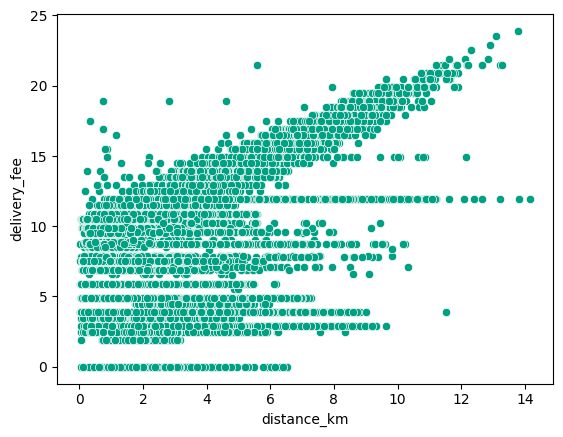

In [ ]:
sns.scatterplot(x=df_mod['distance_km'], y=df_mod['delivery_fee'], color='#00A082')

Se observa una tendencia creciente, a mayor distancia, mayor *delivery_fee*. Esto confirma que la distancia es uno de los principales drivers del coste de entrega. Aunque para un mismo valor de distancia aparecen múltiples precios, esto indica que no solo depende de la distancia. Esta dispersión sugiere que la variable `delivery_fee`también depende de la saturación y otros posibles factores.

Por otro lado, los puntos no forman una nube continua, sino líneas horizontales. Esto indica que el precio no es continuo. El sistema de precios probablemente está basado en rango de distancia.


- `distance_km`

Distribución sesgafa a la derecha. La mayoría de pedidos están entre 1 y 3 km. Los pedidos largos son menos frecuentes, algunos hasta 14km.

- `saturation`

Distribución aproximadatamente unimodal. Rango amplio (20 a 239). Variable clave para explicar tiempos largos.

### **4.2 Análisis de outliers**

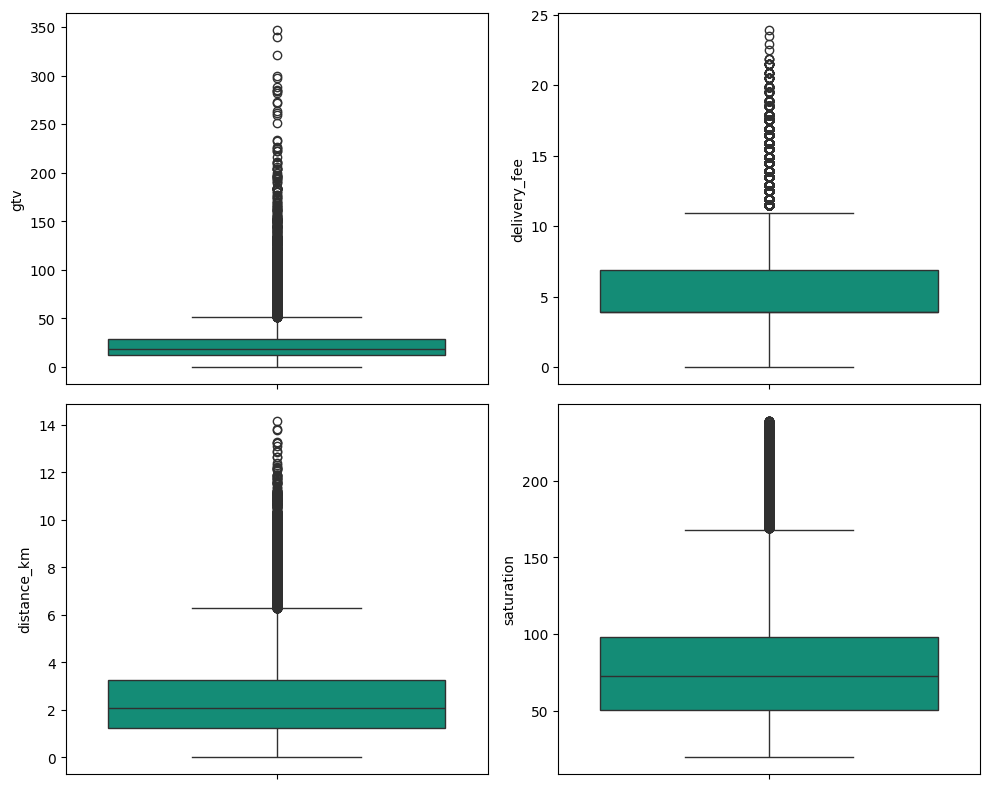

In [ ]:
plt.figure(figsize=(10,8))

for i, col in enumerate(cols_num):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df_mod[col], color='#00A082')

plt.tight_layout()
plt.show()

- `gtv`

Gran cantidad de outliers superiores, pero no son erorres. (**considerar log-transform**).


- `delivery_fee`

Muchos outliers por encima de ~10, etsos reflejan un pricing dinámico.

- `distance_km`

Pedidos largos reales que son importantes para el modelo.

- `saturation`

Los outliers representan picos de demanda, muy relevantes para la predicción.

##**5. Variables categóricas**

In [ ]:
df_mod.describe(include='object').T

,count,unique,top,freq
store_name,63610,568,NO_STORE,11604
vertical,63610,3,WALL - Partner,42104
description,63610,49575,Un sac,415
tranport_type,63610,4,MOTORBIKE,34729


Observaciones relevantes:

- `store_name`

El dataset contiene 567 tiendas distintas. Existe una alta cardinalidad, por lo que probablemente será necesario agrupar o codificar.

- `vertical`

Observamos que solo existen 3 categorías, siendo dominante 'Wall - Partner'. Esto indica un fuerte desbalance entre tipos de servicio.

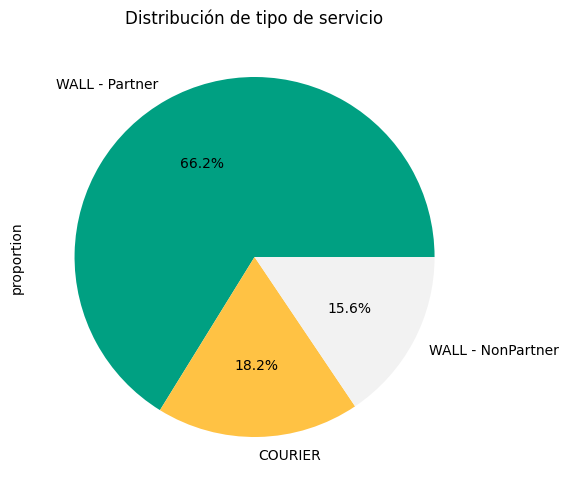

In [ ]:
df_mod.vertical.value_counts(normalize=True).plot(kind='pie', colors=['#00A082', '#FFC244', '#F2F2F2'],  autopct='%1.1f%%')
plt.tight_layout()
plt.title("Distribución de tipo de servicio")
plt.show()

- `transport_type`

Existen 4 tipos distintos de transporte. El más frecuente es 'MOTORBIKE', esto puede ser una variable altamente explicativa del tiempo de entrega.

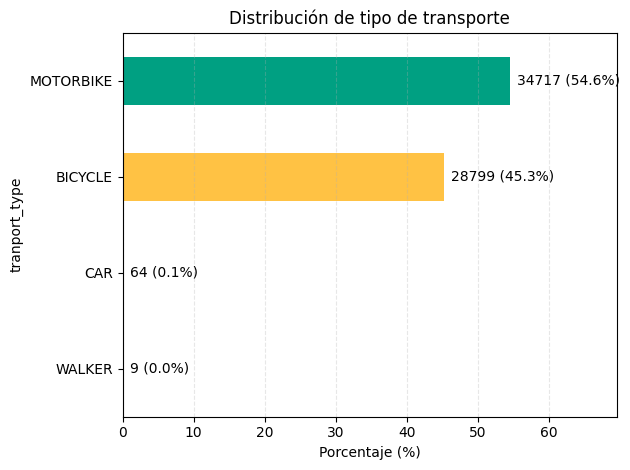

In [ ]:
counts_abs = df_mod['tranport_type'].value_counts()
counts_pct = df_mod['tranport_type'].value_counts(normalize=True) * 100

ax = counts_pct.plot(kind='barh', color=['#00A082', '#FFC244', '#EDEDED', '#004C3E'])

# Añadimos las etiquetas de texto (Recuento + Porcentaje)
for i, (pct, abs_val) in enumerate(zip(counts_pct, counts_abs)):
    ax.text(pct + 1, i, f"{abs_val} ({pct:.1f}%)", va='center', fontsize=10)

plt.xlabel("Porcentaje (%)")
plt.title("Distribución de tipo de transporte")
plt.xlim(0, max(counts_pct) + 15)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- `description`

Altísima cardinanlidad, es texto libre. No es útil directamente ya que contiene ruido elevado.

In [ ]:
df_mod = df_mod.drop(columns=['description'])

## **6. Variables temporales**

Las variables temporales permiten identificar patrones de demanda y su impacto en la operativa logística.

A partir de `activation_time_local`:

In [ ]:
df_mod['hour'] = df_mod['activation_time_local'].dt.hour
df_mod['day_of_week'] = df_mod['activation_time_local'].dt.dayofweek
df_mod['is_weekend'] = df_mod['day_of_week'].isin([5,6]).astype(int)

- **Análisis por hora**

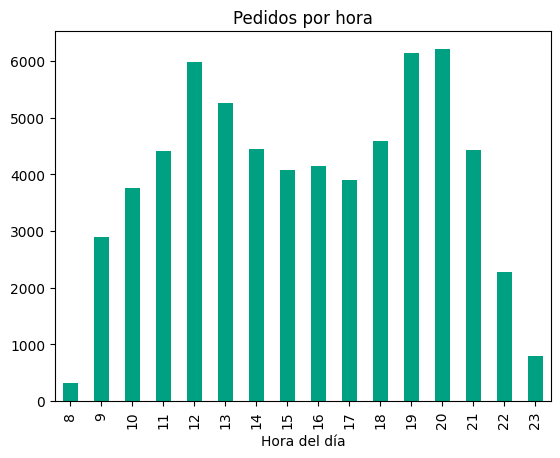

In [ ]:
df_mod['hour'].value_counts().sort_index().plot(kind='bar', color='#00A082')
plt.title("Pedidos por hora")
plt.xlabel("Hora del día")
plt.show()

La demanda presenta una distribución bimodal claramente asociada a los horarios de comida, lo que sugiere que el sistema experimenta picos de carga en franjas muy concretas del día.

- **Análisis por día de la semana**

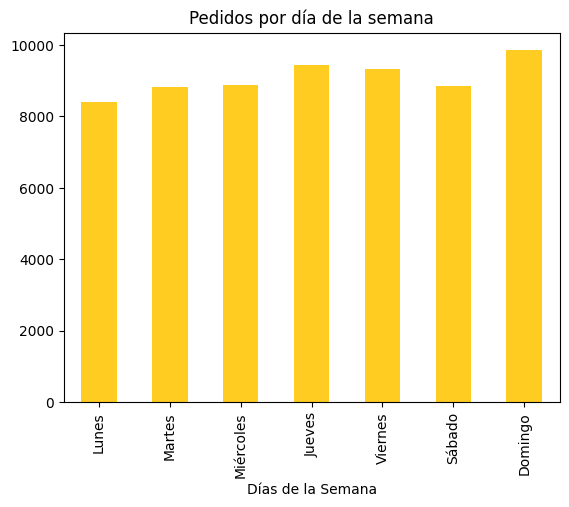

In [ ]:
dias = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}

df_mod['day_name'] = df_mod['day_of_week'].map(dias)

df_mod['day_name'].value_counts().loc[
    ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
].plot(kind='bar', color= '#FFCC22')

plt.title("Pedidos por día de la semana")
plt.xlabel("Días de la Semana")
plt.show()

Existe una variación semanal moderada en la demanda, con mayor actividad hacia el final de la semana y el domingo.

## **7. Construcción de la variable objetivo**

Para analizar y crear la variable objetivo, dado que debemos decidir si es que queremos predecir el *delivery time* desde el *activation time* o desde el courier inicia la orden, debemos analizar estas dos variables.

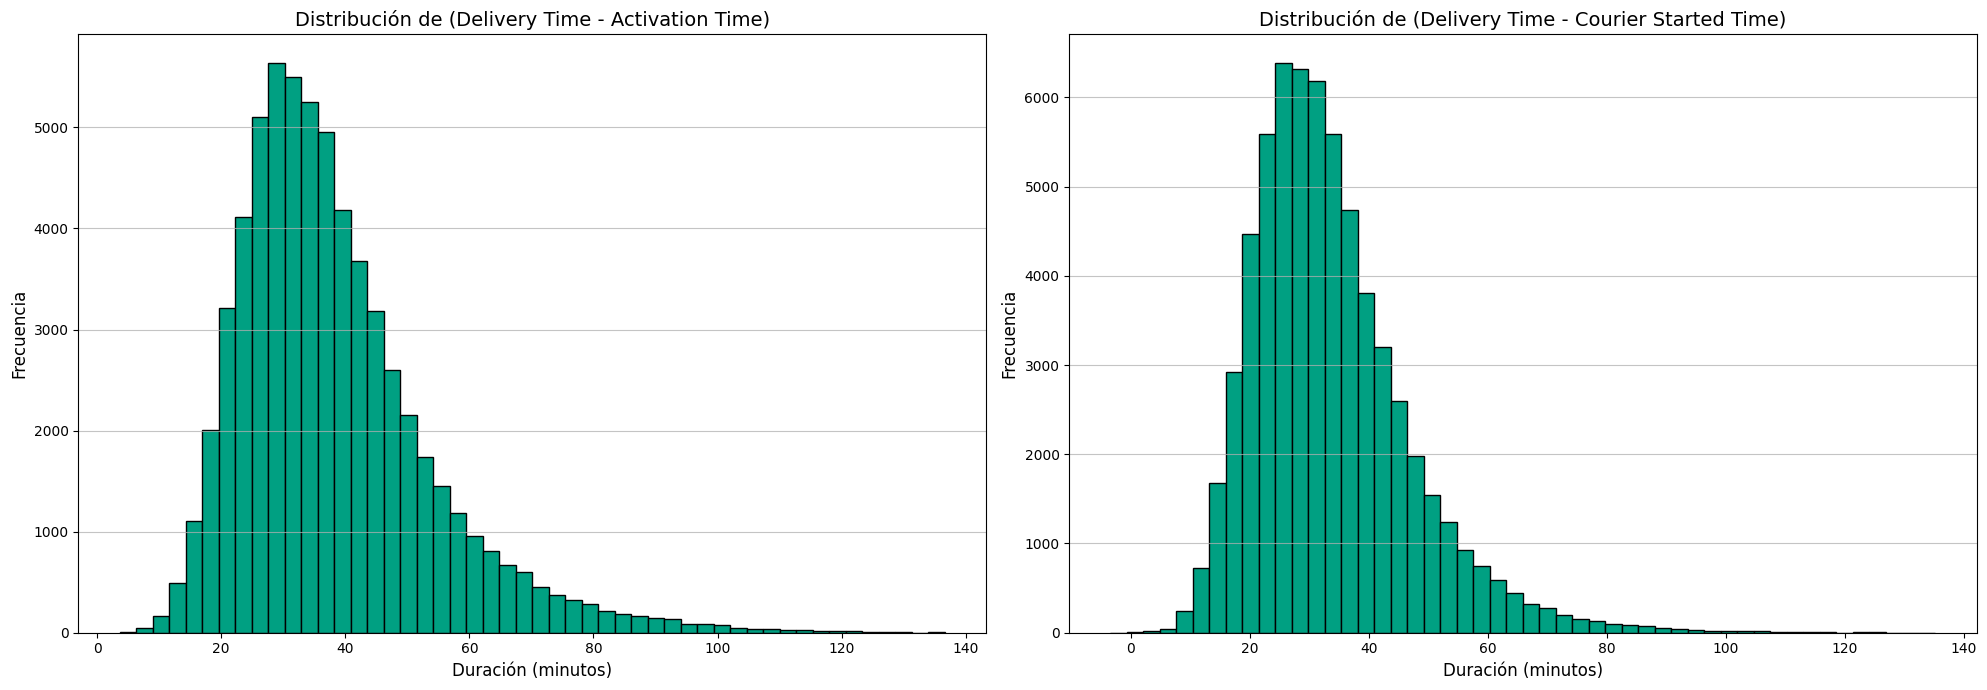

In [ ]:
# Calculamos la diferencia de tiempo entre delivery_time_local y activation_time_local
diff_delivery_activation = (df_mod['delivery_time_local'] - df_mod['activation_time_local']).dt.total_seconds() / 60

# Calculamos la variable objetivo target y target_min
df_mod['target'] = (df_mod['delivery_time_local'] - df_mod['courier_started_order_local'])
df_mod['target_min'] = (df_mod['target'].dt.total_seconds() / 60)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Histograma para (delivery_time_local - activation_time_local)
axes[0].hist(diff_delivery_activation, bins=50, color='#00a082ff', edgecolor='black')
axes[0].set_title('Distribución de (Delivery Time - Activation Time)', fontsize=14)
axes[0].set_xlabel('Duración (minutos)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].grid(axis='y', alpha=0.75)

# Histograma para (delivery_time_local - courier_started_order_local)
axes[1].hist(df_mod['target_min'], bins=50, color='#00a082ff', edgecolor='black')
axes[1].set_title('Distribución de (Delivery Time - Courier Started Time)', fontsize=14)
axes[1].set_xlabel('Duración (minutos)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

Es relevante entender la magnitud de la diferencia entre `activation_time_local` y `courier_started_order_local`. Para lo cual creamos un histograma

📊 Estadísticos de la Diferencia (Minutos):
count    63610.000000
mean         4.554373
std          8.457388
min         -5.908250
25%         -0.106042
50%          2.340867
75%          5.933917
90%         13.077563
95%         20.033667
max        104.125383
Name: delay_minutes, dtype: float64


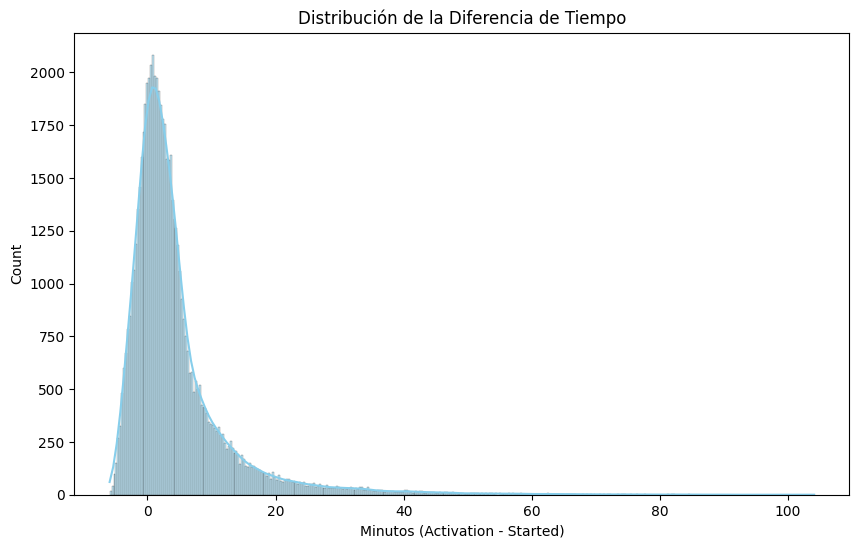

In [ ]:
df_mod['diff_time'] =  df_mod['courier_started_order_local'] - df_mod['activation_time_local']

df_mod['delay_seconds'] = df_mod['diff_time'].dt.total_seconds()
df_mod['delay_minutes'] = df_mod['delay_seconds'] / 60

stats = df_mod['delay_minutes'].describe(percentiles=[.25, .5, .75, .9, .95])
print("📊 Estadísticos de la Diferencia (Minutos):")
print(stats)

plt.figure(figsize=(10, 6))
sns.histplot(df_mod['delay_minutes'], kde=True, color='skyblue')

plt.title('Distribución de la Diferencia de Tiempo')
plt.xlabel('Minutos (Activation - Started)')
plt.show()

Elaboramos un pie chart para ver la cantidad de negativos que existen, lo cual llega a ser un 26.1%. Al ser un cuarto de la data negativa, no podemos simplemente pensar que se trata de algún error.

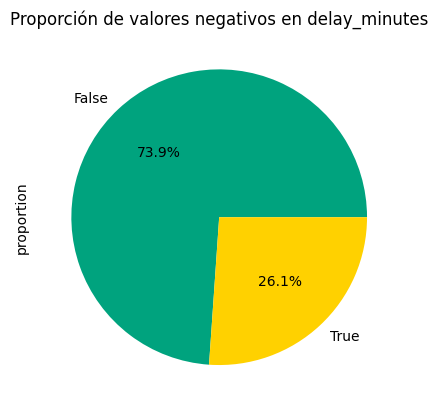

In [ ]:
df_mod['es_negativo'] = df_mod['delay_minutes'] < 0
df_mod['es_negativo'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', colors=['#00A37E', '#FFD100'])
plt.title('Proporción de valores negativos en delay_minutes')
plt.show()

Analizamos los valores negativos en los diferentes rangos de saturación para identificar si es que existe algún comportamiento.

In [ ]:
df_mod['es_negativo'] = df_mod['delay_minutes'] < 0

max_sat = df_mod['saturation'].max()

cortes = np.arange(0, max_sat + 11, 10)

df_mod['sat_bin'] = pd.cut(df_mod['saturation'], bins=cortes)

prop_neg = df_mod.groupby('sat_bin', observed=False)['es_negativo'].mean() * 100

print(prop_neg)

sat_bin
(0, 10]             NaN
(10, 20]      29.545455
(20, 30]      31.971094
(30, 40]      31.202935
(40, 50]      30.372306
(50, 60]      28.779979
(60, 70]      28.982886
(70, 80]      27.611534
(80, 90]      25.341615
(90, 100]     24.465431
(100, 110]    22.235491
(110, 120]    20.038848
(120, 130]    18.995152
(130, 140]    17.592593
(140, 150]    16.099356
(150, 160]    12.817089
(160, 170]    11.132075
(170, 180]     9.018568
(180, 190]     8.303249
(190, 200]     7.762557
(200, 210]    11.023622
(210, 220]    11.000000
(220, 230]    11.111111
(230, 240]    13.043478
Name: es_negativo, dtype: float64


In [ ]:
bins = [0, 50, 100, 150, float('inf')]
labels = ['Baja (0-50)', 'Media (50-100)', 'Alta (100-150)', 'Crítica (+150)']

df_mod['nivel_saturacion'] = pd.cut(df_mod['saturation'], bins=bins, labels=labels)

prop_nivel = (df_mod.groupby('nivel_saturacion', observed=False)['es_negativo'].mean() * 100).round(1)

print(prop_nivel)

nivel_saturacion
Baja (0-50)       31.0
Media (50-100)    27.2
Alta (100-150)    19.9
Crítica (+150)    10.8
Name: es_negativo, dtype: float64


Dado que existe una mayor cantidad de valores negativos iniciando casi en 30% y conforme la saturación aumenta, la cantidad de negativos disminuye podemos concluir que existe un comportamiento de pre-asignación, en donde el sistema pre-asigna en una proporción mayor cuando hay mucha disponibilidad de riders y reduce este comportamiento cuando hay un baja proporción de riders. Es por ello que consideramos relevante setear nuestra variable objetivo cuando el repartidor inicia el pedido hasta cuando se entregue al cliente.

Por lo tanto, el objetivo del modelo es predecir el tiempo total de entrega definido como el intervalo entre:
- inicio del pedido por parte del repartidor
- entrega final al cliente

`target` = `delivery_time_local` - `courier_started_order_local`

### **7.1 Creación de la variable target**

In [ ]:
df_mod['target'] = (df_mod['delivery_time_local'] - df_mod['courier_started_order_local'])

In [ ]:
df_mod['target']

,target
0,0 days 00:30:55.658000
1,0 days 00:19:34.440000
2,0 days 00:30:23.968000
3,0 days 00:38:46.922000
4,0 days 00:27:09.774000
...,...
63641,0 days 00:42:09.912000
63642,0 days 00:34:15.634000
63643,0 days 00:29:07.604000
63644,0 days 00:40:04.370000


Inicialmente, esta variable queda en formato `timedelta` por lo que necesitamos transformarla a una unidad interpretable.

In [ ]:
# Conversión a minutos
df_mod['target_min'] = (df_mod['target'].dt.total_seconds() / 60)

### **7.2 Análisis de la distribución**

Una vez construida la variable objetivo y convertida a minutos, podemos analizar su comportamiento para transformar correctamente el problema en una tarea de clasificación.

In [ ]:
df_mod['target_min'].describe()

,target_min
count,63610.000000
mean,33.571571
std,13.316165
min,-3.427417
25%,24.399117
50%,31.336508
75%,40.112071
max,135.206950


El tiempo medio de entrega se sitúa en ~34 minutos mientras que la mediana está en ~31 minutos, esto indica una ligera asimetría positiva (existencia de pedidos excepcionalmente largos).

Por otro lado, el valor mínimo observado es negativo. Esto no es físicamente posible, por lo que estos registros se eliminan al tratarse de inconsistencias en los datos, probablemente derivadas de errores en la captura de *timestamps*.

In [ ]:
print(f"Número de registros negativos: len{df_mod[df_mod['target_min'] < 0]}")

# Los eliminamos
df_mod = df_mod[df_mod['target_min'] >= 0]

Número de registros negativos: len      store_name           vertical    gtv  delivery_fee  \
2500   Carrefour     WALL - Partner  23.97           3.9   
42925  Starbucks  WALL - NonPartner   7.92           5.9   

      activation_time_local courier_started_order_local  \
2500    2019-10-18 15:08:16     2019-10-18 16:14:12.989   
42925   2019-11-08 09:51:51     2019-11-08 10:37:41.645   

            pickup_time_local delivery_time_local tranport_type  saturation  \
2500  2019-10-18 16:14:47.226 2019-10-18 16:13:09        WALKER         113   
42925 2019-11-08 10:37:39.105 2019-11-08 10:34:16     MOTORBIKE          62   

       ...  is_weekend  day_name                   target  target_min  \
2500   ...           0   Viernes -1 days +23:58:56.011000   -1.066483   
42925  ...           0   Viernes -1 days +23:56:34.355000   -3.427417   

                   diff_time delay_seconds  delay_minutes es_negativo  \
2500  0 days 01:05:56.989000      3956.989      65.949817       False   
429

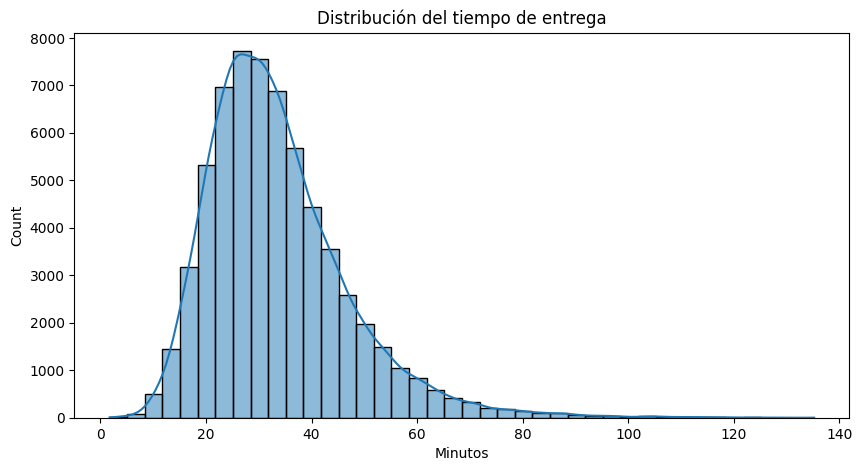

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df_mod['target_min'], bins=40, kde=True)
plt.title("Distribución del tiempo de entrega")
plt.xlabel("Minutos")
plt.show()

El histograma muestra una distribución unimodal, con el pico central entre 25 y 35 minutos. Además presenta una clara asimetría positiva con una cola larga hacia la derecha que alcanza más de 130 minutos.

Se eliminan los pedidos con duración inferior a 5 minutos debido a su escasa representatividad (<0.03%) y a la alta probabilidad de corresponder a errores de medición o casos atípicos no representativos del comportamiento general del sistema.

In [ ]:
len(df_mod[df_mod['target_min'] < 5])

19

In [ ]:
df_mod[df_mod['target_min'] < 5]

,store_name,vertical,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,saturation,...,is_weekend,day_name,target,target_min,diff_time,delay_seconds,delay_minutes,es_negativo,sat_bin,nivel_saturacion
6372,NO_STORE,COURIER,7.80,7.8,2019-11-02 18:41:37,2019-11-02 18:54:58.026,2019-11-02 18:58:02.302,2019-11-02 18:57:00,MOTORBIKE,52,...,1,Sábado,0 days 00:02:01.974000,2.032900,0 days 00:13:21.026000,801.026,13.350433,False,"(50, 60]",Media (50-100)
9157,Miznon,WALL - Partner,11.90,2.9,2019-12-11 14:18:21,2019-12-11 14:24:53.274,2019-12-11 14:24:33.651,2019-12-11 14:29:37,BICYCLE,35,...,0,Miércoles,0 days 00:04:43.726000,4.728767,0 days 00:06:32.274000,392.274,6.537900,False,"(30, 40]",Baja (0-50)
12150,Pizza Odessa,WALL - Partner,16.10,2.5,2019-12-18 13:24:06,2019-12-18 13:32:29.107,2019-12-18 13:33:50.885,2019-12-18 13:37:10,BICYCLE,43,...,0,Miércoles,0 days 00:04:40.893000,4.681550,0 days 00:08:23.107000,503.107,8.385117,False,"(40, 50]",Baja (0-50)
17914,No Smoking,WALL - Partner,22.80,2.9,2019-11-19 16:50:42,2019-11-19 16:49:41.592,2019-11-19 16:55:38.487,2019-11-19 16:54:20,BICYCLE,42,...,0,Martes,0 days 00:04:38.408000,4.640133,-1 days +23:58:59.592000,-60.408,-1.006800,True,"(40, 50]",Baja (0-50)
24618,Out Fry - Chicken Kitchen,WALL - Partner,3.91,3.9,2019-11-15 14:37:52,2019-11-15 14:43:03.081,2019-11-15 14:46:09.982,2019-11-15 14:47:50,BICYCLE,55,...,0,Viernes,0 days 00:04:46.919000,4.781983,0 days 00:05:11.081000,311.081,5.184683,False,"(50, 60]",Media (50-100)
27405,Tabac,WALL - NonPartner,32.10,8.9,2019-11-30 14:01:48,2019-11-30 14:01:36.914,2019-11-30 14:04:39.162,2019-11-30 14:05:47,BICYCLE,41,...,1,Sábado,0 days 00:04:10.086000,4.168100,-1 days +23:59:48.914000,-11.086,-0.184767,True,"(40, 50]",Baja (0-50)
28015,Carrefour,WALL - Partner,8.33,3.9,2019-12-12 17:16:30,2019-12-12 17:49:43.551,2019-12-12 17:55:14.200,2019-12-12 17:52:29,BICYCLE,113,...,0,Jueves,0 days 00:02:45.449000,2.757483,0 days 00:33:13.551000,1993.551,33.225850,False,"(110, 120]",Alta (100-150)
34804,NO_STORE,COURIER,12.50,12.5,2019-10-22 14:21:16,2019-10-22 14:23:34.221,2019-10-22 14:24:50.846,2019-10-22 14:25:22,MOTORBIKE,30,...,0,Martes,0 days 00:01:47.779000,1.796317,0 days 00:02:18.221000,138.221,2.303683,False,"(20, 30]",Baja (0-50)
36945,Carrefour,WALL - Partner,16.34,3.9,2019-11-18 11:37:54,2019-11-18 11:42:10.512,2019-11-18 11:46:05.408,2019-11-18 11:46:21,MOTORBIKE,49,...,0,Lunes,0 days 00:04:10.488000,4.174800,0 days 00:04:16.512000,256.512,4.275200,False,"(40, 50]",Baja (0-50)
39257,Carrefour,WALL - Partner,12.78,3.9,2019-10-22 18:58:41,2019-10-22 19:03:26.768,2019-10-22 19:05:44.547,2019-10-22 19:07:59,MOTORBIKE,45,...,0,Martes,0 days 00:04:32.232000,4.537200,0 days 00:04:45.768000,285.768,4.762800,False,"(40, 50]",Baja (0-50)


In [ ]:
df_mod = df_mod[df_mod['target_min'] >= 5]

### **7.3 Análisis del tiempo de entrega por variables temporales**

- **Tiempo de entrega por hora**

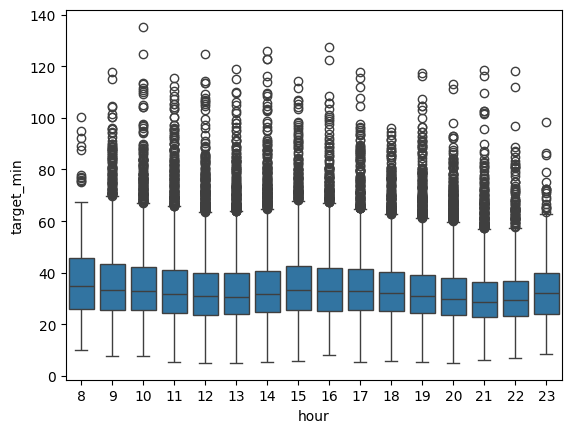

In [ ]:
sns.boxplot(x=df_mod['hour'], y=df_mod['target_min'])
plt.show()

La mediana del tiempo de entrega se mantiene bastante estable, en torno a 30–35 minutos. Sin embargo, se observa una mayor dispersión en horas clave:
- 12–14h (comida)
- 19–21h (cena)

Coincide exactamente con los picos de demanda.

Mientras que las horas con menor variabilidad corresponden a las primeras horas (8.10h) y las últimas horas del día.

Durante las horas de mayor demanda, el sistema presenta mayor variabilidad en los tiempos de entrega, lo que sugiere que la saturación afecta no solo al tiempo medio sino también a la consistencia del servicio.

- **Tiempo de entrega por día de la semana**

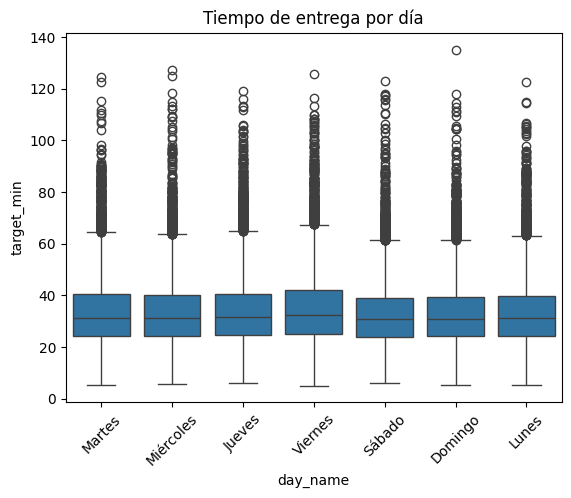

In [ ]:
sns.boxplot(x=df_mod['day_name'], y=df_mod['target_min'])
plt.xticks(rotation=45)
plt.title("Tiempo de entrega por día")
plt.show()

Aunque el tiempo medio de entrega es similar entre días, los fines de semana presentan una mayor variabilidad y más casos extremos, lo que indica una mayor presión operativa.

Las variables temporales serán especialmente útiles para predecir la probabilidad de entregas lentas, más que para diferenciar entre entregas rápidas y medias.

## **8. Discretización de la variable objetivo**

### **8.1 Definición de clases de tiempo de entrega**

Para el desarrollo del modelo predictivo, la variable objetivo se ha categorizado en cinco rangos estratégicos. Esta segmentación no es arbitraria; se fundamenta en una síntesis de las tendencias operativas del sector de última milla, el análisis de competidores de *Quick Commerce* (Q-Commerce) y principios establecidos de la psicología del consumidor.

**1. El estándar del Q-Commerce y la entrega ultra-rápida (5 - 30 min)**

De acuerdo con el *Europe Quick Commerce Market Report*, el éxito de este modelo de negocio reside en satisfacer la necesidad de inmediatez con tiempos de atención inferiores a los 30 minutos. Dentro de este ecosistema, empresas como la alemana *Flink* han redefinido el estándar mediante la implementación de modelos de entrega ultra-rápida en menos de 20 minutos (Fuente: Europe Quick Commerce Market Report https://www.marketdataforecast.com/market-reports/europe-quick-commerce-market). En consecuencia, se definen los primeros dos niveles de servicio:

*   Rango 1 (5 - 20 min): Entregas de alta eficiencia o "Ultra-fast".
*   Rango 2 (20 - 30 min): Estándar competitivo de Q-Commerce.

**2. La "Zona de Indiferencia" y estabilidad emocional (30 - 45 min)**

Para el segmento intermedio, se ha aplicado la teoría de colas propuesta por Richard C. Larson en su estudio *Perspectives on Queues: Social Justice and the Psychology of Queueing*. Larson identifica que los tiempos de espera entre los 30 y 45 minutos suelen ser percibidos por el consumidor de manera similar, sin que se disparen aún niveles críticos de estrés o sensación de injusticia. Por ello, este intervalo se consolida como:
*  Rango 3 (30 - 45 min): Zona de tolerancia operativa.

**3. El límite de la promesa y el fallo de servicio (45 a >60 min)**

Finalmente, la literatura del Q-Commerce establece que los 60 minutos representan una "ventana de tiempo rígida" (*Hard Time-Window*). Superar este umbral implica una ruptura del contrato psicológico con el usuario y una salida del segmento de valor esperado. Pero, aunque en la literatura logística se considera que superar los 60 minutos puede indicar un fallo en la promesa de servicio en contextos de Q-Commerce, el análisis exploratorio revela que parte de estos pedidos corresponden a servicios no inmediatos (como supermercados). Por tanto, este rango no se interpreta exclusivamente como fallo, sino como entregas de mayor duración, potencialmente influenciadas por el tipo de servicio. Esto justifica los últimos dos rangos:
*  Rango 4 (45 - 60 min): Zona de fricción y riesgo de insatisfacción (representa el límite superior para la comida preparada y el estándar de eficiencia para pedidos de supermercado pequeños o medianos.)
*  Rango 5 (> 60 min): Entrega prolongada

### **8.2 Construcción de la variable objetivo categórica**

In [ ]:
def clasificar_tiempo(x):
    if 5 <= x < 20:
        return 0   # muy rápida
    elif 20 <= x < 30:
        return 1   # rápida
    elif 30 <= x < 45:
        return 2   # estándar
    elif 45 <= x < 60:
        return 3   # lenta
    else:
        return 4   # prolongada

df_mod['target_class'] = df_mod['target_min'].apply(clasificar_tiempo)

### **8.3 Distribución de clases**

In [ ]:
df_mod['target_class'].value_counts(normalize=True) * 100

,proportion
target_class,
2,38.475208
1,33.519948
3,12.016229
0,11.692274
4,4.296341


La mayoría de pedidos se concentran en 30–45 min (clase 2).
Distribución razonablemente equilibrada en clases centrales, mientras que las extremas son menos representadas.

Dado que el dataset presenta un desequilibrio de clases significativo, deberemos implementar estrategias de mitigación durante la fase de entrenamiento.

El objetivo es prevenir un sesgo predictivo hacia las clases mayoritarias y asegurar una capacidad de generalización robusta para las clases minoritarias, garantizando así un rendimiento equilibrado en todo el conjunto de datos.

## **9 Relación entre variables**

Dado que la variable objetivo categórica (`target_class`) representa intervalos discretos de tiempo y no una magnitud continua, no resulta adecuado emplear correlación lineal directa. En su lugar, se analiza la relación entre variables numéricas y la variable objetivo continua (`target_min`), complementándolo con análisis por grupos para evaluar diferencias entre clases.

### **9.1 Matriz de correlación**

La matriz de correlación permite evaluar relaciones lineales entre variables numéricas y detectar posibles variables explicativas del tiempo de entrega.

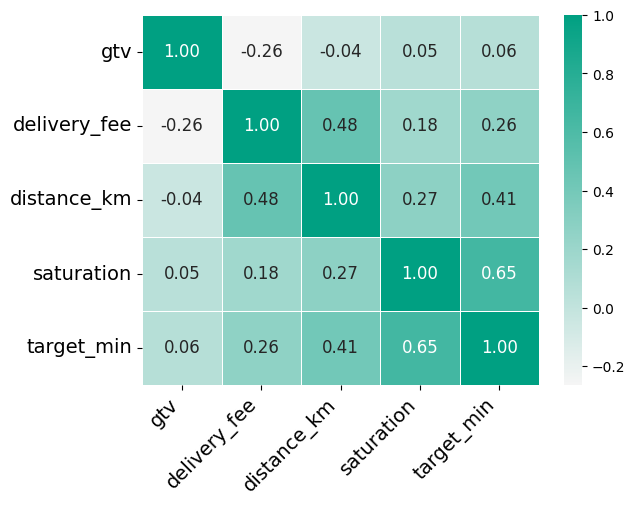

In [ ]:
corr_matrix=df_mod[cols_num + ['target_min']].corr()
GLOVO_COLORS = {
    "green":      "#00A082",
    "yellow":     "#FFC244",
    "gray_dark":  "#333333",
    "gray_light": "#F5F5F5",
}

glovo_cmap = LinearSegmentedColormap.from_list(
    "glovo_green", [GLOVO_COLORS["gray_light"], GLOVO_COLORS["green"]]
)
# Ordenados por clase: 0, 1, 2, 3, 4
plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap=glovo_cmap, fmt=".2f", linewidths=0.5, annot_kws={"size": 12})
plt.xticks(fontsize=14, rotation=45, ha='right') # Rotación para que no se solapen
plt.yticks(fontsize=14)
plt.show()

La matriz de correlación muestra que la variable con mayor relación con el tiempo de entrega es la saturación (0.65), seguida de la distancia (0.41). Esto confirma que tanto la carga operativa del sistema como la distancia geográfica son factores determinantes en el rendimiento del servicio.

Por otro lado, variables como el valor del pedido (gtv) presentan una correlación prácticamente nula, lo que indica que no influyen directamente en el tiempo de entrega.

### **9.2 Relación entre distancia y clases**

El boxplot muestra cómo varía la distancia según la clase de tiempo de entrega.

<Axes: xlabel='target_class', ylabel='distance_km'>

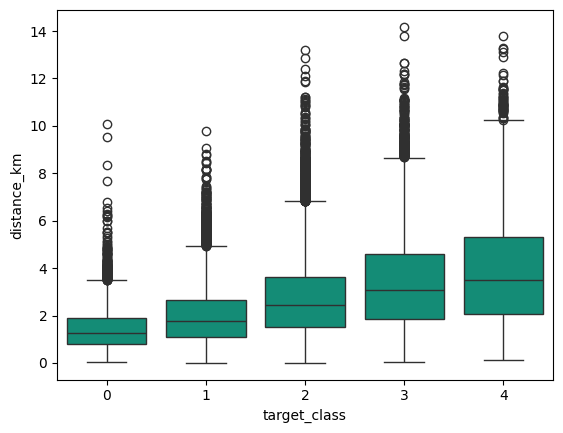

In [ ]:
custom_color = "#00a082"
sns.boxplot(x='target_class', y='distance_km', data=df_mod, color=custom_color)

El análisis mediante boxplots evidencia que, aunque existe una relación creciente entre la distancia y las clases de tiempo, se observa un solapamiento considerable entre ellas. Esto sugiere que el problema no puede explicarse únicamente por la distancia, sino que requiere la combinación de múltiples variables, como la saturación o el tipo de transporte.

### **9.3 Relación entre saturación y clases**

<Axes: xlabel='target_class', ylabel='saturation'>

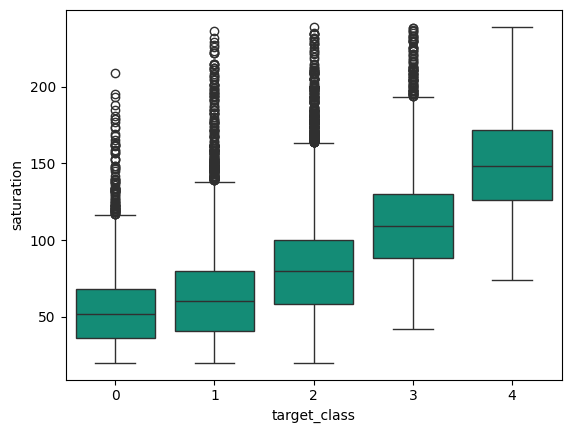

In [ ]:
custom_color = "#00a082"
sns.boxplot(x='target_class', y='saturation', data=df_mod, color=custom_color)

En el gráfico de boxplots se puede evidenciar que si existe una diferencia entre las clases extremas pero un solapamiento parcial en las clases del medio. Posiblemente esta variable tenga una relevancia importante en el modelo